<a name="toc_40291_2"></a>
# Problem Statement

Small Dataset for house price prediction - a house with 1000 square feet sold for \\$300,000 and a house with 2000 square feet sold for \\$500,000.

| Size (1000 sqft)     | Price (1000s of dollars) |
| ----------------| ------------------------ |
| 1               | 300                      |
| 2               | 500                      |


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Get features and label for the dataset
features=np.array([1.0,2.0])
label=np.array([300.0,500.0])

In [3]:
# Compute cost function

def cost_function(w,b,x,y):
    m=x.shape[0]
    total=0
    pred=np.zeros(m)
    for i in range(m):
        pred[i]=(w*x[i])+b
        total+=(pred[i]-y[i])**2
    return total/(2*m)

<a name="toc_40291_2.1"></a>
## Gradient descent
Linear regression model that predicts $f_{w,b}(x^{(i)})$:
$$f_{w,b}(x^{(i)}) = wx^{(i)} + b \tag{1}$$
we use input training data to fit the parameters $w$,$b$ by minimizing a measure of the error between our predictions $f_{w,b}(x^{(i)})$ and the actual data $y^{(i)}$. The measure is called the $cost$, $J(w,b)$. In training you measure the cost over all of our training samples $x^{(i)},y^{(i)}$
$$J(w,b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})^2\tag{2}$$ 


*gradient descent* is described as:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline
\;  w &= w -  \alpha \frac{\partial J(w,b)}{\partial w} \tag{3}  \; \newline 
 b &= b -  \alpha \frac{\partial J(w,b)}{\partial b}  \newline \rbrace
\end{align*}$$
where, parameters $w$, $b$ are updated simultaneously.  
The gradient is defined as:
$$
\begin{align}
\frac{\partial J(w,b)}{\partial w}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)})x^{(i)} \tag{4}\\
  \frac{\partial J(w,b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{w,b}(x^{(i)}) - y^{(i)}) \tag{5}\\
\end{align}
$$



In [4]:
# Compute gradient

def gradient(w,b,x,y):
    m=x.shape[0]
    sum_bias_gradient=0
    sum_weight_gradient=0
    pred=np.zeros(m)
    for i in range(m):
        pred[i]=(w*x[i])+b
        sum_weight_gradient+=(pred[i]-y[i])*x[i]
        sum_bias_gradient+=(pred[i]-y[i])
    weight_gradient=sum_weight_gradient/m
    bias_gradient=sum_bias_gradient/m
    return weight_gradient,bias_gradient

In [5]:
# gradient descent
def gradient_descent(x,y,iteration,learning_rate):
    m=x.shape[0]
    pred=np.zeros(m)
    weight=0
    bias=0
    cost_history=[]
    iteration_history=[]
    for i in range(iteration):
        weight_gradient,bias_gradient=gradient(weight,bias,features,label)
        weight=weight-(learning_rate*weight_gradient)
        bias=bias-(learning_rate*bias_gradient)
        if i%10==0:
            iteration_history.append(i)
            cost=cost_function(weight,bias,x,y)
            cost_history.append(cost)
            #print(f"Weight: {weight} Bias: {bias} Cost:{cost}  ")
    return weight,bias,cost_history,iteration_history

weight,bias,cost_history,iteration_history=gradient_descent(features,label,100000,0.001)

# prediction 
def prediction(x):
    return ((weight*x)+bias)


### Cost versus iterations of gradient descent 

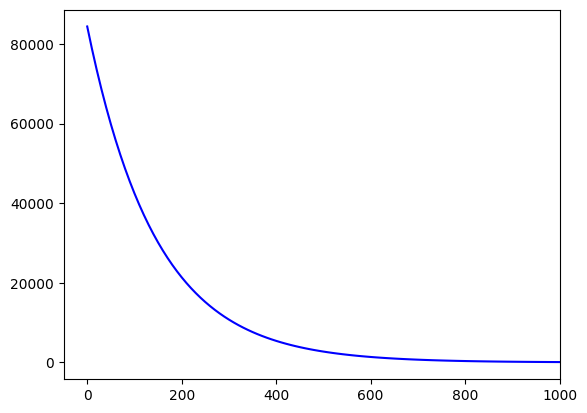

In [6]:
plt.plot(iteration_history,cost_history,c='b')
plt.xlim(-50, 1000)
plt.show()

### Make model prediction

In [7]:

print(f" The model prediction is {prediction(1.0):.0f}  ")
print(f" The model prediction is {prediction(1.2):.0f}  ")
print(f" The model prediction is {prediction(2.0):.0f}  ")

 The model prediction is 300  
 The model prediction is 340  
 The model prediction is 500  
